# Tira 0

In [1]:
import roboticstoolbox as rtb
import spatialmath as sm
import numpy as np

## Ejercicio 1
Dada la matriz de rotación $R$, obtener el cuaternión $Q$ que la representa.

$$
 R=\left[
 \begin{array}{rrr}
 -1/3 & -2/3 & 2/3 \\
 -2/3 & -1/3 & -2/3 \\
 2/3 & -2/3 & -1/3 
 \end{array} \right]
$$

Comprobar el resultado mediante el problema directo de los cuaterniones.


In [17]:
Rmat = np.array([[-1/3 , -2/3 , 2/3],
[-2/3 , -1/3 , -2/3],
[2/3 , -2/3 , -1/3]])

R = sm.SO3(Rmat)
print(R)

Q = R.UnitQuaternion()

print("Cuaternión unitario Q=",Q)
print("Recupero la matriz de rotación R=\n",Q.R)



  -0.3333   -0.6667    0.6667    
  -0.6667   -0.3333   -0.6667    
   0.6667   -0.6667   -0.3333    

Cuaternión unitario Q=  0.0000 <<  0.5774, -0.5774,  0.5774 >>
Recupero la matriz de rotación R=
 [[-0.33333333 -0.66666667  0.66666667]
 [-0.66666667 -0.33333333 -0.66666667]
 [ 0.66666667 -0.66666667 -0.33333333]]


## Ejercicio 2

Dada la matriz de rotación $R$, obtener el cuaternión $Q$ que la representa.

$$
 R=\left[
 \begin{array}{rrr}
 -1 & 0 & 0 \\
 0 & 0 & -1 \\
 0 & -1 & 0 
 \end{array} \right]
$$

Comprobar el resultado mediante el problema directo de los cuaterniones.

In [26]:
Rmat = np.array([[-1 , 0 , 0],
[0 , 0 , -1],
[0 , -1 , 0]])

R = sm.SO3(Rmat)
print(R)

# Verifico que esta matriz corresponde a una singularidad del problema de los cuaterniones
th,k = R.angvec()
print(th,k)
# Una rotación de th=180 da el mismo resultado que una de -180 sobre el mismo eje

Q = R.UnitQuaternion()
Q2 = -Q

print("Cuaternión unitario solución 1    Q1=",Q)
print("Cuaternión unitario solución 2    Q2=",Q2)
print("Recupero la matriz de rotación R1=\n",np.round(Q.R,6))
print("Recupero la matriz de rotación R2=\n",np.round(Q2.R))

# Notar que esto mismo ocurría en el ejercicio anterior


  -1         0         0         
   0         0        -1         
   0        -1         0         

3.141592653589793 [ 0.          0.70710678 -0.70710678]
Cuaternión unitario solución 1    Q1=  0.0000 <<  0.0000,  0.7071, -0.7071 >>
Cuaternión unitario solución 2    Q2= -0.0000 << -0.0000, -0.7071,  0.7071 >>
Recupero la matriz de rotación R1=
 [[-1.  0.  0.]
 [ 0. -0. -1.]
 [-0. -1. -0.]]
Recupero la matriz de rotación R2=
 [[-1.  0.  0.]
 [ 0. -0. -1.]
 [-0. -1. -0.]]


# Ejercicio 3

Dadas dos rotaciones sucesivas, la primera sobre el eje $\vec{Z}$ en $\pi/2$, y la segunda sobre el eje $\vec{X}_\mathtt{rotado}$ también en $\pi/2$, obtener:
- la matriz $R$ que la representa.
- los cuaterniones $Q_1$ y $Q_2$ asociados a cada rotación y componer el cuaternión resultante. 
- la matriz $R_{rec}$ y cotejarla con la hallada anteriormente.

In [37]:
R1 = sm.SO3.AngleAxis(np.pi/2,[0,0,1])
R2 = sm.SO3.AngleAxis(np.pi/2,[1,0,0])

R = R1 @ R2
print("R=",R)

Q1 = R1.UnitQuaternion()
Q2 = R2.UnitQuaternion()
print("Q1=",Q1)
print("Q2=",Q2)

Q = Q1*Q2
print("Q=Q1*Q2=",Q)

R_rec = Q.R
print(np.round(R_rec,6))

R=    0         0         1         
   1         0         0         
   0         1         0         

Q1=  0.7071 <<  0.0000,  0.0000,  0.7071 >>
Q2=  0.7071 <<  0.7071,  0.0000,  0.0000 >>
Q=Q1*Q2=  0.5000 <<  0.5000,  0.5000,  0.5000 >>
[[ 0. -0.  1.]
 [ 1.  0. -0.]
 [ 0.  1.  0.]]


## Ejercicio 4

Dado el esquema de la figura se pide:
- obtener del gráfico las matrices $A^1_0$ , $A^2_1$ y $A^2_0$ ,
- calcular $A^2_0$ a partir de $A^1_0$ y $A^2_1$ comprobando el resultado

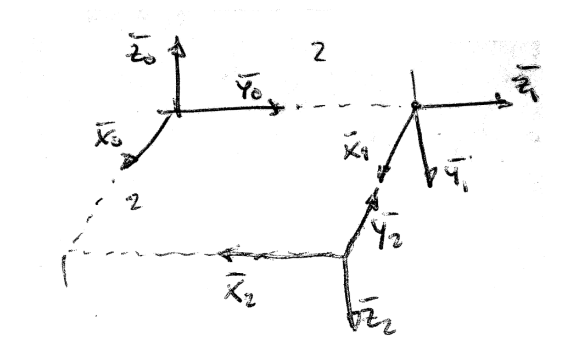

In [48]:
R10 = np.array([[1,0,0],[0,0,-1],[0,1,0]]).T
A_10 = sm.SE3.Rt(R10,[0,2,0])
print("A_10=\n",A_10)

R21 = np.array([[0,0,-1],[-1,0,0],[0,1,0]]).T
A_21 = sm.SE3.Rt(R21,[2,0,0])
print("A_21=\n",A_21)


R20 = np.array([[0,-1,0],[-1,0,0],[0,0,-1]]).T
A_20 = sm.SE3.Rt(R20,[2,2,0])
print("A_20=\n",A_20)

print("A_10 * A_21 = \n",A_10 @ A_21)

A_10=
    1         0         0         0         
   0         0         1         2         
   0        -1         0         0         
   0         0         0         1         

A_21=
    0        -1         0         2         
   0         0         1         0         
  -1         0         0         0         
   0         0         0         1         

A_20=
    0        -1         0         2         
  -1         0         0         2         
   0         0        -1         0         
   0         0         0         1         

A_10 * A_21 = 
    0        -1         0         2         
  -1         0         0         2         
   0         0        -1         0         
   0         0         0         1         

